In [ ]:
!pip install ase dscribe

print("Everything works!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 773.7/773.7 kB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.3/155.3 kB 10.0 MB/s eta 0:00:00
Everything works!


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving train.json to train.json
Saving test.json to test.json


In [ ]:
import os
import gc
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sn
import scipy as sci
from ase import Atoms
from tqdm import tqdm
from tqdm.notebook import tqdm as nb_tqdm

from sklearn import model_selection
from dscribe.descriptors import MBTR
from dscribe.descriptors import CoulombMatrix
from dscribe.descriptors import SOAP

import scipy.sparse as sp

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader,TensorDataset

use_cuda = torch.cuda.is_available()
use_mps = torch.backends.mps.is_available()

print("Use cuda?:", use_cuda)

if use_cuda:
    device = torch.device('cuda')
    print('Running on Nvidia GPU (cuda)')
elif use_mps:
    device = torch.device('mps')
    print('Running on Apple Silicon GPU device (mps)')
else:
    device = torch.device('cpu')
    print('Running on CPU')

rng = np.random.default_rng()

Use cuda?: False
Running on CPU


In [ ]:
path_train = "./train.json"
path_test = "./test.json"

train_data = pd.read_json(path_train)
test_data = pd.read_json(path_test)

train_data.atoms = train_data.atoms.apply(lambda x: Atoms(**x))
test_data.atoms = test_data.atoms.apply(lambda x: Atoms(**x))

In [ ]:
# get atomic numbers in the dataset
species = sorted(
    set(
        Z for atoms in train_data.atoms
        for Z in atoms.get_atomic_numbers()
    )
)

soap = SOAP(
    species=species,
    r_cut=5.0,
    n_max=6,    # was 8, reduced to save memory
    l_max=4,    # was 6, reduced to save memory
    sigma=0.5,
    periodic=True,
    average="outer",
    compression={"mode":"mu1nu1","species_weighting": None},
    sparse=False,          # very very very important for memory
    dtype="float32"       # halves memory usage
)

In [ ]:
if not os.path.exists("X_train_soap.npz"):
    print("Computing SOAP descriptors (this may take a while)...")

    X_train = soap.create(
    train_data.atoms,
    n_jobs=1
    )

    X_test = soap.create(
    test_data.atoms,
    n_jobs=1
    )

    y_train = train_data.hform.values

    # these two lines are important to avoid a format issue
    # X_train = X_train.tocsr()
    # X_test  = X_test.tocsr()

    np.save("X_train_soap.npy", X_train)
    np.save("X_test_soap.npy", X_test)
    np.save("y_train.npy", y_train)

    print("SOAP descriptors computed and saved.")

# if they do exist, this section will just load them
else:
    print("Loading cached SOAP descriptors...")

    X_train = sp.load_npz("X_train_soap.npz")
    X_test  = sp.load_npz("X_test_soap.npz")
    y_train = np.load("y_train.npy")

    print("SOAP descriptors loaded.")

N,M = X_train.shape
X_train.shape
X_test.shape

Computing SOAP descriptors (this may take a while)...
SOAP descriptors computed and saved.


(4000, 11160)

## Train Neural Network (Cross-Validation)

In [ ]:
class IndexedDataset(torch.utils.data.Dataset):
    def __init__(self, X, y, indices):
        self.X = X
        self.y = y
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        return self.X[idx], self.y[idx]

def count_parameters(model):
	"Returns number of trainable parameters."
	return sum(p.numel() for p in model.parameters() if p.requires_grad)

def normalize_data(data):
	#normalize data
	print(f"Normalize data...")
	X_train,X_test,y_train,y_test = data

	mean = X_train.mean(dim=0, keepdim=True)
	std  = X_train.std(dim=0, keepdim=True) + 1e-8

	X_train = (X_train - mean) / std
	X_test  = (X_test  - mean) / std

	mean = y_train.mean(dim=0, keepdim=True)
	std  = y_train.std(dim=0, keepdim=True) + 1e-8
	y_train = (y_train - mean)/std
	y_test = (y_test - mean)/std
	print(f"Done!")
	return [X_train,X_test,y_train,y_test]


def train_network(model,device,train_loader,lossfunc,optimizer,epoch,return_model=False,verbose=False):
	"""Train model for a single epoch.

	Parameters:
	model:         PyTorch model to train.
	device:        Device used for training (i.e. cpu, gpu, ...)
	train_loader:  Data loader
	optimizer:     The optimizer used in the training.
	epoch:         Epoch number
	"""
	model.train()  # Put model in training mode
	losses  = []
	for batch_idx, (data, target) in enumerate(train_loader):
		data, target = data.to(device), target.to(device)

		optimizer.zero_grad()
		output = model(data)
		loss = lossfunc(output, target)
		loss.backward()
		losses.append(loss.item())
		optimizer.step()
		# Print progress
		if verbose:
			ndone = batch_idx * len(data)
			ntot = len(train_loader.dataset)
			percent = 100 * ndone / ntot
			print(f'Train epoch: {epoch} [{ndone}/{ntot} ({percent:.0f}%)]\tLoss: {loss.item():.6f}')
	avg_loss = np.array(losses).mean()

	#if epoch%5 == 0: print(f"Train epoch: {epoch}. loss = {np.sqrt(avg_loss)}")

	if return_model == True:
		return model,avg_loss
	return avg_loss

def test_network(model, device, test_loader, lossfunc, epoch):
	model.eval()
	test_losses = []

	with torch.no_grad():
		for data,target in test_loader:
			data,target = data.to(device),target.to(device)
			output = model(data)
			loss = lossfunc(output,target)
			test_losses.append(loss.item())

	test_loss = np.array(test_losses).mean()
	#print(f'Test set, epoch {epoch}: Average loss: {test_loss:.4f}')
	return test_loss


def neural_network_cross_validation(X,y,neural_net_setup,lossfunc,nepochs,device,K,display=False):
	# note: in the future this should just accept a neural_network object which has the 'net','optimizer','lossfunc' as well as 'nepochs' defined as attributes
	# note 2: in the future this function should also be a class to make accessing errors easier

	# turn our data into torch tensors:

	#X = torch.tensor(X, dtype=torch.float32)
	#y = torch.tensor(y, dtype=torch.float32).view(-1,1)

	X = torch.from_numpy(X).float()
	y = torch.from_numpy(y).float().view(-1,1)


	cv_train_losses = []
	CV_test_losses = np.zeros(K)

	CV = model_selection.KFold(K,shuffle=True)

	print("Start cross validation...")

	y_train_vars = np.zeros(K)
	y_test_vars = np.zeros(K)

	# This is the crossvalidation loop where we train a neural network on each split of the data
	best_loss = 1e9
	best_model = None
	best_idx = 0
	for cv_idx, (train_idx, test_idx) in enumerate(CV.split(X,y)):
		print(f"Cross validation loop #{cv_idx+1}")

		# split the data
		print(f"Create data splits...")
		X_train = X[train_idx]								# can be replaced
		X_test = X[test_idx]								# can be replaced

		y_train = y[train_idx]								# can be replaced
		y_test = y[test_idx]								# can be replaced
		print(f"Done!")

		y_var = torch.var(y_train).item()					# compare this with rmse of the model on the test data
		y_train_vars[cv_idx] = y_var

		# create dataset and dataloaders
		train_dataset = torch.utils.data.TensorDataset(X_train, y_train)		# can be replaced
		test_dataset = torch.utils.data.TensorDataset(X_test, y_test)			# can be replaced

		# use this if memory becomes an issue and delete the above 2+4 sets of lines
		#train_dataset = IndexedDataset(X, y, train_idx)
		#test_dataset  = IndexedDataset(X, y, test_idx)

		train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=3000, shuffle=True)
		test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=256, shuffle=True)

		print("Create model")
		model = neural_net_setup().to(device)
		#optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
		optimizer = torch.optim.AdamW(model.parameters(),lr=1e-4,weight_decay=1e-5)
		print("Model created")

		number_of_parameters = count_parameters(model)
		print(f"Model has {number_of_parameters:.3e} parameters ({number_of_parameters*32/1e6} [MB]).")


		best_val_rmse = np.inf
		best_state = None
		patience = 20
		patience_counter = 0

		train_errors = []
		test_errors = []
		# train neural network! on the last iteration we will return both the model and the average loss
		print(f"Start training the network. Training data consists of {len(X_train)} data points and testing data of {len(X_test)}\n")
		for epoch in nb_tqdm(range(nepochs)):
			loss = train_network(
								model,device,train_loader,lossfunc,optimizer,
								epoch,return_model=False
								)
			mean_loss = test_network(
									model, device, test_loader, lossfunc, epoch
									)
			RMSE = np.sqrt(loss)	# root mean squared error
			train_errors.append(RMSE)

			# test the neural network by calculating the root mean squared error on the "test data"

			test_rmse = np.sqrt(mean_loss)
			test_errors.append(test_rmse)

			# early stopping logic
			tol = 1e-4
			if test_rmse < best_val_rmse-tol:
					best_val_rmse = test_rmse
					best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
					patience_counter = 0
			else:
				patience_counter += 1

			if patience_counter >= patience:
				print(f"Early stopping at epoch {epoch}")
				break

		cv_train_losses.append(train_errors)

		CV_test_losses[cv_idx] = best_val_rmse

		print(f"Testing done! root mean square error = {test_rmse}. variance of y_train: {y_var}\n")

		if test_rmse < best_loss:
			best_loss = test_rmse
			best_model = model

		if best_state is not None:
			model.load_state_dict(best_state)

	print(f"CV losses = {CV_test_losses}")
	print(f"Best model was #{np.argmin(CV_test_losses)+1}(index {np.argmin(CV_test_losses)})")

	if display == True:

		fig,ax = plt.subplots()
		ax.set_xlabel("epoch #",fontsize=15)
		ax.set_ylabel("RMSE",fontsize=15)
		for i,training_errors in enumerate(cv_train_losses):
			ax.plot(np.arange(0,len(training_errors)),training_errors,label=f"CV Fold #{i}",zorder=0)
		ax.plot(np.arange(0,len(cv_train_losses[best_idx])),cv_train_losses[best_idx],c='red',lw=2.0,label="best model",zorder=2)
		ax.legend()

		fig2,ax2 = plt.subplots()
		ax2.set_xlabel("epoch #",fontsize=15)
		ax2.set_ylabel("-log(RMSE)",fontsize=15)

		for i,training_errors in enumerate(cv_train_losses):
			ax2.plot(np.arange(0,len(training_errors)),-np.log10(training_errors),label=f"CV Fold #{i}",zorder=0)
		ax2.plot(np.arange(0,len(cv_train_losses[best_idx])),-np.log10(cv_train_losses[best_idx]),c='red',lw=2.0,label="best model",zorder=2)

		ax2.legend()
		fig3,ax3 = plt.subplots()
		ax3.set_xlabel("CV Fold #",fontsize=15)
		ax3.set_xticks(np.arange(0,K+0.01,1))
		ax3.scatter(np.arange(0,K),y_train_vars,c='red',marker='o',s=100)
		ax3.scatter(np.arange(0,K),CV_test_losses,c='green',marker='d',s=100)
		# Draw vertical lines and annotate distances
		for i in range(K):
			y1 = y_train_vars[i]
			y2 = CV_test_losses[i]
			x = i

			# Draw vertical line
			ax3.plot([x, x], [y1, y2], 'k--', alpha=0.7)

			# Annotate the distance in the middle of the line
			y_mid = (y1 + y2) / 2
			distance = abs(y2 - y1)
			ax3.text(x, y_mid, f'{distance:.2f}', ha='center', va='center', fontsize=9, backgroundcolor='w')

			# Annotate the y-values at each end
			ax3.text(x, y1+0.01, f'{y1:.3f}', ha='right', va='bottom', fontsize=8, color='red')
			ax3.text(x, y2+0.01, f'{y2:.3f}', ha='left', va='bottom', fontsize=8, color='green')

	# clean up the kitchen
	del X_train
	del X_test
	del y_train
	del y_test
	del model
	del optimizer
	gc.collect()

	return best_model,best_loss

Start cross validation...
Cross validation loop #1
Create data splits...
Done!
Create model
Model created
Model has 5.895e+06 parameters (188.649504 [MB]).
Start training the network. Training data consists of 7000 data points and testing data of 1000



  0%|          | 0/200 [00:00<?, ?it/s]

Testing done! root mean square error = 0.14860913195177558. variance of y_train: 0.4809928238391876

Cross validation loop #2
Create data splits...
Done!
Create model
Model created
Model has 5.895e+06 parameters (188.649504 [MB]).
Start training the network. Training data consists of 7000 data points and testing data of 1000



  0%|          | 0/200 [00:00<?, ?it/s]

Testing done! root mean square error = 0.12958403871149804. variance of y_train: 0.4836811423301697

Cross validation loop #3
Create data splits...
Done!
Create model
Model created
Model has 5.895e+06 parameters (188.649504 [MB]).
Start training the network. Training data consists of 7000 data points and testing data of 1000



...

Testing done! root mean square error = 0.12758831165709958. variance of y_train: 0.4811388850212097

Cross validation loop #7
Create data splits...
Done!
Create model
Model created
Model has 5.895e+06 parameters (188.649504 [MB]).
Start training the network. Training data consists of 7000 data points and testing data of 1000



  0%|          | 0/200 [00:00<?, ?it/s]

Testing done! root mean square error = 0.1510876674251263. variance of y_train: 0.4817289113998413

Cross validation loop #8
Create data splits...
Done!
Create model
Model created
Model has 5.895e+06 parameters (188.649504 [MB]).
Start training the network. Training data consists of 7000 data points and testing data of 1000



  0%|          | 0/200 [00:00<?, ?it/s]

Early stopping at epoch 191
Testing done! root mean square error = 0.14505421499878124. variance of y_train: 0.48414143919944763

CV losses = [0.14715037 0.12922972 0.13750772 0.12187203 0.13559782 0.12732181
 0.1496707  0.14324571]
Best model was #4(index 3)


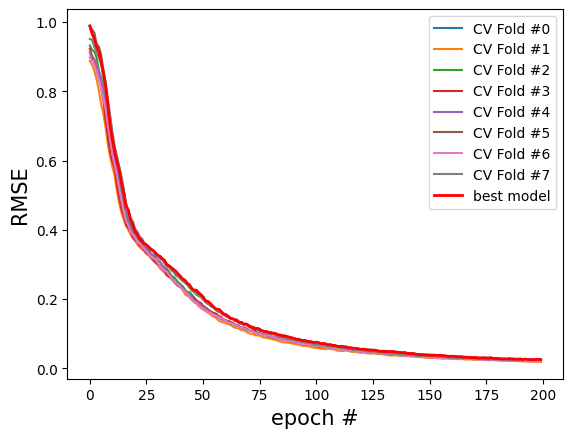

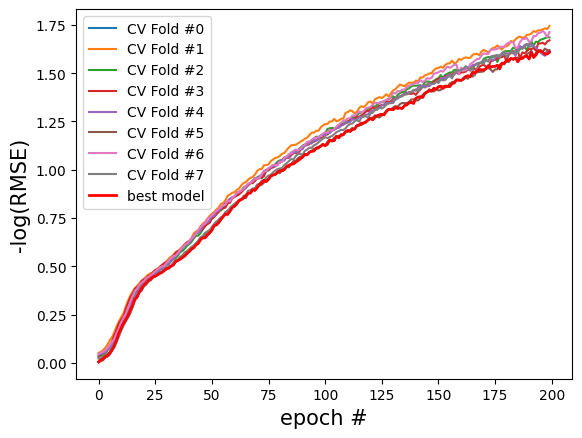

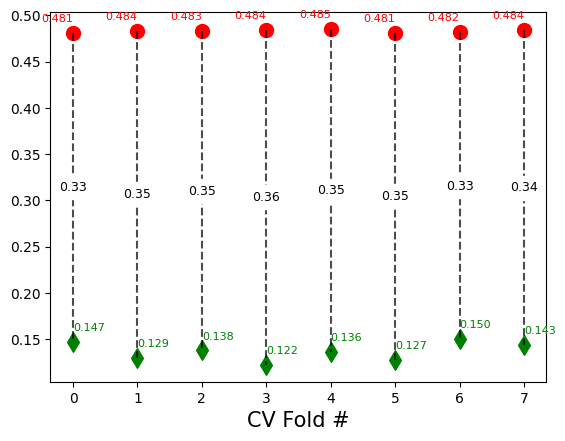

In [ ]:
# do the cross validation!
neural_net_setup = lambda: torch.nn.Sequential(
					torch.nn.Linear(M, 512),	# M features to n hidden units
					torch.nn.LeakyReLU(),
                    torch.nn.Linear(512,256),
					torch.nn.LeakyReLU(),
                    torch.nn.Linear(256,128),
					torch.nn.LeakyReLU(),
                    torch.nn.Linear(128,128),
					torch.nn.LeakyReLU(),
                    torch.nn.Linear(128,1)# n hidden units to one scalar value
					)

lossfunc = torch.nn.MSELoss()

K = 8 	# number of cross-validation folds
nepoch = 200
model, loss = neural_network_cross_validation(X_train,y_train,neural_net_setup,
                                              lossfunc,nepoch,device,K,display=True)

In [ ]:
# Test the best model on the dataset not used for cross validation
model.eval()
output = model((torch.from_numpy(X_test).float()).to(device))
values = np.array(output.cpu().detach().numpy()).flatten()
print(output)
print(values)

submission = pd.DataFrame({
    "id": test_data.id,
    "hform": values
})

submission.to_csv("submission.csv", index=False)

tensor([[-0.3368],
        [-0.5697],
        [-1.0453],
        ...,
        [-0.5095],
        [-0.0403],
        [-0.9076]], grad_fn=<AddmmBackward0>)
[-0.3368088  -0.56970775 -1.0452967  ... -0.50945145 -0.04025698
 -0.9076127 ]


### Concurrent training of networks

In [ ]:
from concurrent.futures import ThreadPoolExecutor

def concurrent_cross_validation(X, y, neural_net_setup, lossfunc, nepochs, device, K, display=False):
    X = torch.from_numpy(X).float()
    y = torch.from_numpy(y).float().view(-1, 1)

    cv_train_losses = []
    CV_test_losses = np.zeros(K)
    y_train_vars = np.zeros(K)

    CV = model_selection.KFold(K, shuffle=True)

    best_loss = 1e9
    best_model = None

    # Prepare fold data ahead
    folds = [(cv_idx, train_idx, test_idx) for cv_idx, (train_idx, test_idx) in enumerate(CV.split(X, y))]

    def train_fold(cv_idx, train_idx, test_idx):
        torch.cuda.empty_cache()
        gc.collect()

        X_train = X[train_idx].to(device)
        X_test = X[test_idx].to(device)
        y_train = y[train_idx].to(device)
        y_test = y[test_idx].to(device)


        y_var = torch.var(y_train).item()

        train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
        test_dataset = torch.utils.data.TensorDataset(X_test, y_test)

        train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=1000, shuffle=True)
        test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=256, shuffle=False)

        model = neural_net_setup().to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

        losses = []
        for epoch in range(nepochs):
            model.train()
            batch_losses = []
            for xb, yb in train_loader:
                optimizer.zero_grad()
                preds = model(xb)
                loss = lossfunc(preds, yb)
                loss.backward()
                optimizer.step()
                batch_losses.append(loss.item())
            losses.append(np.sqrt(np.mean(batch_losses)))

        # Evaluate test loss
        model.eval()
        with torch.no_grad():
            test_losses = []
            for xb, yb in test_loader:
                preds = model(xb)
                loss = lossfunc(preds, yb)
                test_losses.append(loss.item())
            test_rmse = np.sqrt(np.mean(test_losses))

        # Clean GPU memory before returning
        del X_train, X_test, y_train, y_test, train_dataset, test_dataset, train_loader, test_loader
        torch.cuda.empty_cache()
        gc.collect()

        return cv_idx, losses, test_rmse, y_var, model

    print("Start concurrent cross-validation...")

    # Execute 2 folds at a time
    with ThreadPoolExecutor(max_workers=4) as executor:
        futures = [executor.submit(train_fold, cv_idx, train_idx, test_idx) for cv_idx, train_idx, test_idx in folds]
        for f in tqdm(futures):
            cv_idx, losses, test_rmse, y_var, model = f.result()
            cv_train_losses.append(losses)
            CV_test_losses[cv_idx] = test_rmse
            y_train_vars[cv_idx] = y_var
            if test_rmse < best_loss:
                best_loss = test_rmse
                best_model = model

    best_idx = np.argmin(CV_test_losses)

    print(f"CV losses = {CV_test_losses}")
    print(f"Best model was #{best_idx+1} (index {best_idx})")

    if display:
        fig, ax = plt.subplots()
        ax.set_xlabel("epoch #", fontsize=15)
        ax.set_ylabel("RMSE", fontsize=15)
        nmin,nmax = 50,nepochs
        for i, training_errors in enumerate(cv_train_losses):
            ax.plot(np.arange(nmin, nmax), training_errors[nmin:nmax], label=f"CV Fold #{i}")
        ax.plot(np.arange(nmin, nmax), cv_train_losses[best_idx][nmin:nmax], c='red', lw=2.0, label="best model")
        ax.legend()

        fig2, ax2 = plt.subplots()
        ax2.set_xlabel("CV Fold #", fontsize=15)

        ax2.scatter(np.arange(0, K), y_train_vars, c='red', marker='o', s=100)
        ax2.scatter(np.arange(0, K), CV_test_losses, c='green', marker='d', s=100)
        for i in range(K):
            y1 = y_train_vars[i]
            y2 = CV_test_losses[i]
            x = i
            ax2.plot([x, x], [y1, y2], 'k--', alpha=0.7)
            y_mid = (y1 + y2) / 2
            distance = abs(y2 - y1)
            ax2.text(x, y_mid, f'{distance:.2f}', ha='center', va='center', fontsize=9, backgroundcolor='w')
            ax2.text(x, y1 + 0.01, f'{y1:.3f}', ha='right', va='bottom', fontsize=8, color='red')
            ax2.text(x, y2 + 0.01, f'{y2:.3f}', ha='left', va='bottom', fontsize=8, color='green')

    return best_model, best_loss


In [ ]:
N,M = X_train.shape
neural_net_setup = lambda: torch.nn.Sequential(
					torch.nn.Linear(M, 2048),	# M features to n hidden units
					torch.nn.Sigmoid(),
                    torch.nn.Linear(2048,1)
                    #torch.nn.Linear(2048,512),	# hidden layer
                    #torch.nn.Sigmoid(),
                    #torch.nn.Linear(512,256),	# hidden layer
                    #torch.nn.Sigmoid(),
                    #torch.nn.Linear(n_hidden,n_hidden),	# hidden layer
                    #torch.nn.Sigmoid(),
                    #torch.nn.Linear(n_hidden,n_hidden),	# hidden layer
                    #torch.nn.Sigmoid(),
					#torch.nn.Linear(256,1),	# n hidden units to one scalar value
					)

lossfunc = torch.nn.MSELoss()

K = 8 	# number of cross-validation folds
nepoch = 200
model, loss = concurrent_cross_validation(X_train,y_train,neural_net_setup,
                                              lossfunc,nepoch,device,K,display=True)

Start concurrent cross-validation...


  0%|          | 0/8 [00:00<?, ?it/s]